# Chapter 3 — The Schelling Segregation Model
**Modeling Social Behavior** | Smaldino

This notebook builds Schelling's segregation model from scratch in Python.
The model shows how mild individual preferences for similar neighbors produce
strong population-level segregation — a classic example of **emergence** in ABM.

---

### Model Summary
- **Space:** A discrete square grid (square lattice) with toroidal boundaries
- **Agents:** Each agent occupies one cell and has a color (group identity)
- **Rule:** If the proportion of same-color neighbors is below `similarity_threshold` → move to a random empty cell
- **Outcome:** We measure **average similarity** — the mean proportion of same-color neighbors across all agents

---

### Variable Guide
Throughout this notebook, variables are labeled by scope:
- 🌐 **Global** — shared across the whole simulation
- 🤖 **Agent** — stored per agent (in the agents DataFrame)
- 📍 **Local** — temporary, used only inside a function


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## 2. Global Parameters

These are the 🌐 **global variables** that define the simulation setup.
They are set once and shared across all functions.

| Parameter | Type | Description |
|---|---|---|
| `GRID_SIZE` | 🌐 Global | Number of rows and columns in the square grid |
| `DENSITY` | 🌐 Global | Proportion of cells that are occupied by agents (0–1) |
| `SIMILARITY_THRESHOLD` | 🌐 Global | Minimum proportion of same-color neighbors for an agent to be happy |
| `N_COLORS` | 🌐 Global | Number of groups (colors) in the population |
| `SEED` | 🌐 Global | Random seed for reproducibility |


In [2]:
# ── 🌐 GLOBAL PARAMETERS ──────────────────────────────────────────────────────

GRID_SIZE = 51             # The grid is GRID_SIZE x GRID_SIZE cells
                           # 51 gives a 51x51 = 2601-cell lattice

DENSITY = 0.90             # Proportion of cells that will be occupied
                           # 0.90 means ~90% of cells have an agent

SIMILARITY_THRESHOLD = 0.30  # An agent is happy if at least 30% of its
                              # neighbors share its color; otherwise it moves

N_COLORS = 2               # Number of distinct groups (colors)
                           # Minimum 2 needed for any interesting dynamics

SEED = 42                  # Random seed — set this for reproducible results
np.random.seed(SEED)

# Derived global: total number of cells
N_CELLS = GRID_SIZE * GRID_SIZE  # 🌐 Global — total cells in the grid

print(f"Grid:       {GRID_SIZE} x {GRID_SIZE} = {N_CELLS} cells")
print(f"Density:    {DENSITY}")
print(f"Threshold:  {SIMILARITY_THRESHOLD}")
print(f"Max agents: {int(N_CELLS * DENSITY)}")


Grid:       51 x 51 = 2601 cells
Density:    0.9
Threshold:  0.3
Max agents: 2340


## 3. Initialization — Building the World

We represent agents as rows in a **pandas DataFrame**. Each row is one agent.

### Agent variables (🤖)
Each agent has the following properties:

| Column | Type | Description |
|---|---|---|
| `row` | 🤖 Agent | Row index of the agent's cell on the grid |
| `col` | 🤖 Agent | Column index of the agent's cell on the grid |
| `color` | 🤖 Agent | Group identity (integer 0 or 1 for two groups) |
| `happy` | 🤖 Agent | Boolean — is this agent currently satisfied? |
| `prop_similar` | 🤖 Agent | Proportion of neighbors that share this agent's color |

### How initialization works
1. Loop over every cell in the grid
2. With probability `DENSITY`, place an agent there
3. Assign each agent a random color (group identity)
4. Start `happy` and `prop_similar` as placeholders — they'll be computed next


In [3]:
def initialize_agents(grid_size, density, n_colors):
    """
    Create the initial population of agents placed randomly on the grid.

    Parameters
    ----------
    grid_size : int   🌐 — size of one side of the square grid
    density   : float 🌐 — probability that any given cell is occupied
    n_colors  : int   🌐 — number of distinct agent groups (colors)

    Returns
    -------
    agents : pd.DataFrame — one row per agent, with columns:
             row, col, color, happy, prop_similar
    """

    records = []  # 📍 Local — temporary list to collect agent data

    for r in range(grid_size):          # 📍 Local — row index
        for c in range(grid_size):      # 📍 Local — column index

            # Place an agent here with probability = density
            if np.random.random() < density:
                records.append({
                    'row':          r,
                    'col':          c,
                    'color':        np.random.randint(0, n_colors),  # random group
                    'happy':        False,    # placeholder — updated later
                    'prop_similar': 0.0       # placeholder — updated later
                })

    agents = pd.DataFrame(records)
    return agents


# ── Initialize the simulation ─────────────────────────────────────────────────
agents = initialize_agents(GRID_SIZE, DENSITY, N_COLORS)  # 🌐 Global agent table

print(f"Total agents created: {len(agents)}")
print(f"Color 0 (group A):    {(agents['color'] == 0).sum()}")
print(f"Color 1 (group B):    {(agents['color'] == 1).sum()}")
agents.head(8)


Total agents created: 2359
Color 0 (group A):    1211
Color 1 (group B):    1148


,row,col,color,happy,prop_similar
0,0,0,0,False,0.0
1,0,1,1,False,0.0
2,0,2,0,False,0.0
3,0,3,0,False,0.0
4,0,4,1,False,0.0
5,0,5,1,False,0.0
6,0,6,1,False,0.0
7,0,7,1,False,0.0


## 4. Grid Lookup — Mapping Agents to Cells

Many operations require knowing which agent (if any) is at a given (row, col).
We build a **lookup dictionary** that maps `(row, col) → agent index`.

This replaces scanning the full DataFrame every time — much faster.

We also implement **toroidal boundaries** here: when a cell is at the edge of
the grid, its neighbors wrap around to the other side. This ensures all agents
have the same number of neighbors and eliminates boundary effects.


In [4]:
def build_grid_lookup(agents, grid_size):
    """
    Build a dictionary mapping (row, col) → DataFrame index for fast lookup.

    Parameters
    ----------
    agents    : pd.DataFrame  — the agent table
    grid_size : int           🌐 — grid dimension

    Returns
    -------
    grid : dict — keys are (row, col) tuples, values are agent DataFrame indices
    """
    grid = {}  # 📍 Local — will become the returned lookup dict

    for idx, agent in agents.iterrows():  # 📍 Local — idx is the DataFrame index
        grid[(int(agent['row']), int(agent['col']))] = idx

    return grid


def get_moore_neighbors(row, col, grid_size):
    """
    Return the (row, col) coordinates of the 8 Moore neighbors of a cell.
    Uses TOROIDAL boundaries — edges wrap around.

    The Moore neighborhood is the 8 cells immediately surrounding the focal cell,
    including diagonals. With radius r=1, that's always exactly 8 cells.

    Toroidal wrap: neighbor coordinates are taken modulo grid_size,
    so row -1 wraps to row grid_size-1, and row grid_size wraps to row 0.

    Parameters
    ----------
    row, col  : int  🤖 — position of the focal agent
    grid_size : int  🌐 — grid dimension (for wrapping)

    Returns
    -------
    neighbors : list of (row, col) tuples — the 8 surrounding cells
    """
    neighbors = []  # 📍 Local — list of neighbor coordinates

    for dr in [-1, 0, 1]:           # 📍 Local — row offset (-1, 0, +1)
        for dc in [-1, 0, 1]:       # 📍 Local — col offset (-1, 0, +1)
            if dr == 0 and dc == 0:
                continue            # Skip the focal cell itself

            # Toroidal wrap using modulo arithmetic
            nr = (row + dr) % grid_size   # 📍 Local — neighbor row (wrapped)
            nc = (col + dc) % grid_size   # 📍 Local — neighbor col (wrapped)
            neighbors.append((nr, nc))

    return neighbors  # Always exactly 8 neighbors


# ── Quick test ────────────────────────────────────────────────────────────────
# Corner cell (0,0) should wrap to include cells on the far edges
corner_neighbors = get_moore_neighbors(0, 0, GRID_SIZE)
print(f"Moore neighbors of corner cell (0,0): {corner_neighbors}")
print(f"Total neighbors returned: {len(corner_neighbors)}  ← should always be 8")


Moore neighbors of corner cell (0,0): [(50, 50), (50, 0), (50, 1), (0, 50), (0, 1), (1, 50), (1, 0), (1, 1)]
Total neighbors returned: 8  ← should always be 8


## 5. Updating Agent States — Happy or Unhappy?

Each time step, we recompute two 🤖 agent variables for every agent:

- `prop_similar` — what fraction of this agent's occupied neighbors share its color?
- `happy` — is `prop_similar >= SIMILARITY_THRESHOLD`?

### Special case: isolated agents
If an agent has **zero occupied neighbors**, we set `prop_similar = 1.0`
(treat it as fully satisfied). This matches Smaldino's original code:
an agent alone on the grid has no one to be dissatisfied with.


In [5]:
def update_agents(agents, grid, grid_size, similarity_threshold):
    """
    Recompute prop_similar and happy for every agent.

    For each agent:
      1. Find its 8 Moore neighbors (with toroidal wrap)
      2. Count how many neighbor cells are occupied
      3. Of those, count how many share the agent's color
      4. Compute prop_similar = same-color neighbors / total occupied neighbors
      5. Set happy = (prop_similar >= similarity_threshold)

    Parameters
    ----------
    agents               : pd.DataFrame  — agent table (modified in place)
    grid                 : dict          — (row,col) → agent index lookup
    grid_size            : int           🌐
    similarity_threshold : float         🌐

    Returns
    -------
    None — agents DataFrame is updated in place
    """

    for idx, agent in agents.iterrows():

        # Get the 8 Moore neighbor coordinates (with toroidal wrap)
        neighbor_cells = get_moore_neighbors(
            int(agent['row']), int(agent['col']), grid_size
        )  # 📍 Local — list of (row, col) tuples

        # Count occupied neighbors and same-color neighbors
        total_nearby   = 0   # 📍 Local — how many neighbor cells are occupied
        similar_nearby = 0   # 📍 Local — how many of those share this agent's color

        for cell in neighbor_cells:          # 📍 Local — one neighbor cell
            if cell in grid:                 # Is there an agent at this cell?
                total_nearby += 1
                neighbor_color = agents.at[grid[cell], 'color']  # 📍 Local
                if neighbor_color == agent['color']:
                    similar_nearby += 1

        # Compute proportion of similar neighbors
        # Special case: if no neighbors at all, treat agent as fully happy
        if total_nearby == 0:
            prop_sim = 1.0   # 📍 Local — isolated agent is always satisfied
        else:
            prop_sim = similar_nearby / total_nearby  # 📍 Local

        # Write back to the agent table
        agents.at[idx, 'prop_similar'] = prop_sim
        agents.at[idx, 'happy'] = (prop_sim >= similarity_threshold)


# ── Run first update ──────────────────────────────────────────────────────────
grid = build_grid_lookup(agents, GRID_SIZE)  # 🌐 Global — (row,col) → index dict
update_agents(agents, grid, GRID_SIZE, SIMILARITY_THRESHOLD)

n_happy   = agents['happy'].sum()
n_unhappy = (~agents['happy']).sum()
print(f"After initialization:")
print(f"  Happy agents:   {n_happy}  ({n_happy/len(agents)*100:.1f}%)")
print(f"  Unhappy agents: {n_unhappy}  ({n_unhappy/len(agents)*100:.1f}%)")


After initialization:
  Happy agents:   1942  (82.3%)
  Unhappy agents: 417  (17.7%)


## 6. Global Outcome Measures

These are the 🌐 **global outcome variables** we track across time:

| Variable | Description |
|---|---|
| `average_similarity` | Mean of `prop_similar` across all agents — our main segregation metric |
| `unhappiness` | Proportion of agents who are currently unhappy (want to move) |

**Baseline:** With two equally-sized groups randomly placed and no segregation,
`average_similarity` ≈ 0.5. Values above 0.5 indicate population-level segregation.


In [6]:
def compute_globals(agents):
    """
    Compute population-level outcome measures from the current agent states.

    Parameters
    ----------
    agents : pd.DataFrame — agent table with current prop_similar and happy values

    Returns
    -------
    average_similarity : float 🌐 — mean proportion of same-color neighbors
    unhappiness        : float 🌐 — proportion of agents who are unhappy
    """
    # 🌐 average_similarity: mean of each agent's prop_similar
    average_similarity = agents['prop_similar'].mean()

    # 🌐 unhappiness: fraction of agents where happy == False
    unhappiness = (~agents['happy']).mean()

    return average_similarity, unhappiness


# ── Test ──────────────────────────────────────────────────────────────────────
avg_sim, unhappy = compute_globals(agents)
print(f"Average similarity: {avg_sim:.3f}  (baseline ≈ 0.5 for random placement)")
print(f"Unhappiness:        {unhappy:.3f}  (proportion of agents wanting to move)")


Average similarity: 0.496  (baseline ≈ 0.5 for random placement)
Unhappiness:        0.177  (proportion of agents wanting to move)


## 7. Moving Unhappy Agents

Unhappy agents search for a random empty cell and relocate there.

### The rule (from Smaldino):
> *If the proportion of my neighbors who are the same color as I am is below
> my tolerance threshold → move to a random empty cell. Otherwise → stay.*

Key details:
- Only **unhappy** agents move
- They move to a **randomly chosen empty cell** — no strategic search
- The grid lookup dictionary must be **updated** after each move
- Agents move one at a time, in random order


In [7]:
def move_unhappy_agents(agents, grid, grid_size):
    """
    For each unhappy agent, move it to a randomly chosen empty cell.

    The agent picks a random empty cell from those currently unoccupied
    and relocates there. The grid lookup is updated immediately after
    each move so subsequent agents see the updated occupancy.

    Parameters
    ----------
    agents    : pd.DataFrame — agent table (modified in place)
    grid      : dict         — (row,col) → agent index lookup (modified in place)
    grid_size : int          🌐

    Returns
    -------
    None — agents and grid are updated in place
    """

    # Find all currently occupied cells
    occupied = set(grid.keys())  # 📍 Local — set of (row,col) that have agents

    # Build the full set of all cells in the grid
    all_cells = {
        (r, c)
        for r in range(grid_size)
        for c in range(grid_size)
    }  # 📍 Local

    # Get indices of unhappy agents, shuffled for random ordering
    unhappy_indices = agents.index[~agents['happy']].tolist()  # 📍 Local
    np.random.shuffle(unhappy_indices)

    for idx in unhappy_indices:  # 📍 Local — one unhappy agent index at a time

        # Recompute empty cells (occupancy changes as agents move)
        empty_cells = list(all_cells - occupied)  # 📍 Local

        if len(empty_cells) == 0:
            break  # No empty cells left — stop moving

        # Pick a random empty cell as the new home
        new_pos = empty_cells[np.random.randint(len(empty_cells))]  # 📍 Local

        # Get the agent's current position
        old_row = int(agents.at[idx, 'row'])  # 📍 Local
        old_col = int(agents.at[idx, 'col'])  # 📍 Local

        # Remove old position from the grid lookup and occupied set
        del grid[(old_row, old_col)]
        occupied.discard((old_row, old_col))

        # Update the agent's position in the DataFrame
        agents.at[idx, 'row'] = new_pos[0]
        agents.at[idx, 'col'] = new_pos[1]

        # Add new position to the grid lookup and occupied set
        grid[new_pos] = idx
        occupied.add(new_pos)


## 8. Visualization — Drawing the Grid

Before running the full simulation, we build a function to visualize the
current state of the grid as a colored heatmap.

- **Yellow cells** = Group 0 agents
- **Blue cells** = Group 1 agents
- **White cells** = Empty (no agent)


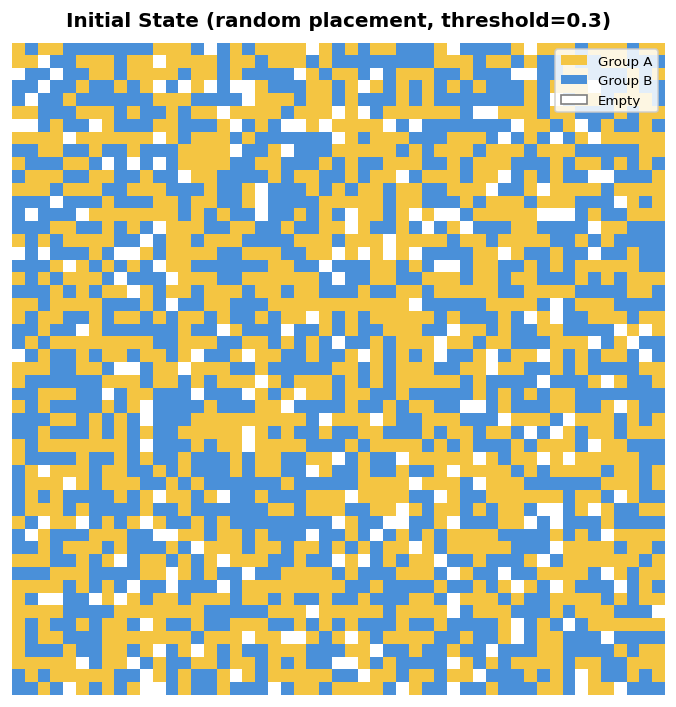

In [8]:
def draw_grid(agents, grid_size, title='', ax=None):
    """
    Draw the current state of the grid as a colored image.

    Each cell is colored by the agent's group (color), or white if empty.

    Parameters
    ----------
    agents    : pd.DataFrame — agent table with row, col, color columns
    grid_size : int          🌐
    title     : str          — plot title
    ax        : matplotlib Axes, optional — if None, a new figure is created
    """

    # Build a 2D grid array: -1 = empty, 0 = group 0, 1 = group 1
    # 📍 Local — grid_array is only used for rendering
    grid_array = np.full((grid_size, grid_size), -1, dtype=int)

    for _, agent in agents.iterrows():
        r = int(agent['row'])
        c = int(agent['col'])
        grid_array[r, c] = int(agent['color'])

    # Build a custom colormap: white for empty, yellow for group 0, blue for group 1
    cmap = mcolors.ListedColormap(['white', '#F4C542', '#4A90D9'])  # 📍 Local
    bounds = [-1.5, -0.5, 0.5, 1.5]                                 # 📍 Local
    norm   = mcolors.BoundaryNorm(bounds, cmap.N)                    # 📍 Local

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(grid_array, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

    # Legend
    legend_elements = [
        Patch(facecolor='#F4C542', label='Group A'),
        Patch(facecolor='#4A90D9', label='Group B'),
        Patch(facecolor='white',   edgecolor='gray', label='Empty'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              fontsize=8, framealpha=0.85)


# ── Draw the initial (random) state ──────────────────────────────────────────
draw_grid(agents, GRID_SIZE, title=f'Initial State (random placement, threshold={SIMILARITY_THRESHOLD})')
plt.tight_layout()
plt.show()


## 9. The Main Simulation Loop

Now we put it all together. Each time step (tick) does the following:

1. **Check for equilibrium** — if all agents are happy, stop
2. **Move unhappy agents** — each unhappy agent relocates to a random empty cell
3. **Update agent states** — recompute `prop_similar` and `happy` for all agents
4. **Record global outcomes** — store `average_similarity` and `unhappiness`

The simulation runs until equilibrium (no unhappy agents) or `max_ticks` is reached.


In [9]:
def run_simulation(grid_size, density, similarity_threshold, n_colors,
                   max_ticks=500, seed=None):
    """
    Run the full Schelling segregation simulation from setup to equilibrium.

    Parameters
    ----------
    grid_size            : int   🌐 — side length of the square grid
    density              : float 🌐 — proportion of cells occupied
    similarity_threshold : float 🌐 — happiness threshold
    n_colors             : int   🌐 — number of agent groups
    max_ticks            : int   🌐 — maximum number of time steps before stopping
    seed                 : int       — random seed for reproducibility

    Returns
    -------
    agents       : pd.DataFrame — final agent states
    history      : pd.DataFrame — time series of average_similarity and unhappiness
    ticks_run    : int          — number of ticks actually executed
    """

    if seed is not None:
        np.random.seed(seed)

    # ── SETUP ─────────────────────────────────────────────────────────────────
    agents = initialize_agents(grid_size, density, n_colors)
    grid   = build_grid_lookup(agents, grid_size)
    update_agents(agents, grid, grid_size, similarity_threshold)

    # 📍 Local — lists to accumulate time-series data
    sim_history = []

    # Record the initial state (tick 0)
    avg_sim, unhappy = compute_globals(agents)
    sim_history.append({'tick': 0,
                        'average_similarity': avg_sim,
                        'unhappiness': unhappy})

    # ── MAIN LOOP ─────────────────────────────────────────────────────────────
    for tick in range(1, max_ticks + 1):  # 📍 Local — current time step

        # Stop if all agents are happy (equilibrium reached)
        if agents['happy'].all():
            print(f"  ✓ Equilibrium reached at tick {tick - 1}")
            break

        # Step 1: move unhappy agents to random empty cells
        move_unhappy_agents(agents, grid, grid_size)

        # Step 2: recompute happiness for all agents
        update_agents(agents, grid, grid_size, similarity_threshold)

        # Step 3: record global outcomes for this tick
        avg_sim, unhappy = compute_globals(agents)
        sim_history.append({'tick': tick,
                            'average_similarity': avg_sim,
                            'unhappiness': unhappy})

    else:
        # Loop completed without hitting equilibrium
        print(f"  ⚠ Max ticks ({max_ticks}) reached without equilibrium")

    history   = pd.DataFrame(sim_history)
    ticks_run = len(history) - 1  # subtract the tick-0 entry

    return agents, history, ticks_run


# ── RUN ───────────────────────────────────────────────────────────────────────
print(f"Running simulation: grid={GRID_SIZE}x{GRID_SIZE}, "
      f"density={DENSITY}, threshold={SIMILARITY_THRESHOLD}")

agents, history, ticks_run = run_simulation(
    grid_size            = GRID_SIZE,
    density              = DENSITY,
    similarity_threshold = SIMILARITY_THRESHOLD,
    n_colors             = N_COLORS,
    max_ticks            = 500,
    seed                 = SEED
)

print(f"  Ticks run:          {ticks_run}")
print(f"  Final avg similarity: {history['average_similarity'].iloc[-1]:.3f}")
print(f"  Final unhappiness:    {history['unhappiness'].iloc[-1]:.3f}")


Running simulation: grid=51x51, density=0.9, threshold=0.3
  ✓ Equilibrium reached at tick 9
  Ticks run:          9
  Final avg similarity: 0.738
  Final unhappiness:    0.000


## 10. Results — Before, After, and Time Series

We now visualize three things:
1. **Initial state** — random placement before any movement
2. **Final state** — the segregated equilibrium
3. **Time series** — how `average_similarity` and `unhappiness` evolved over time


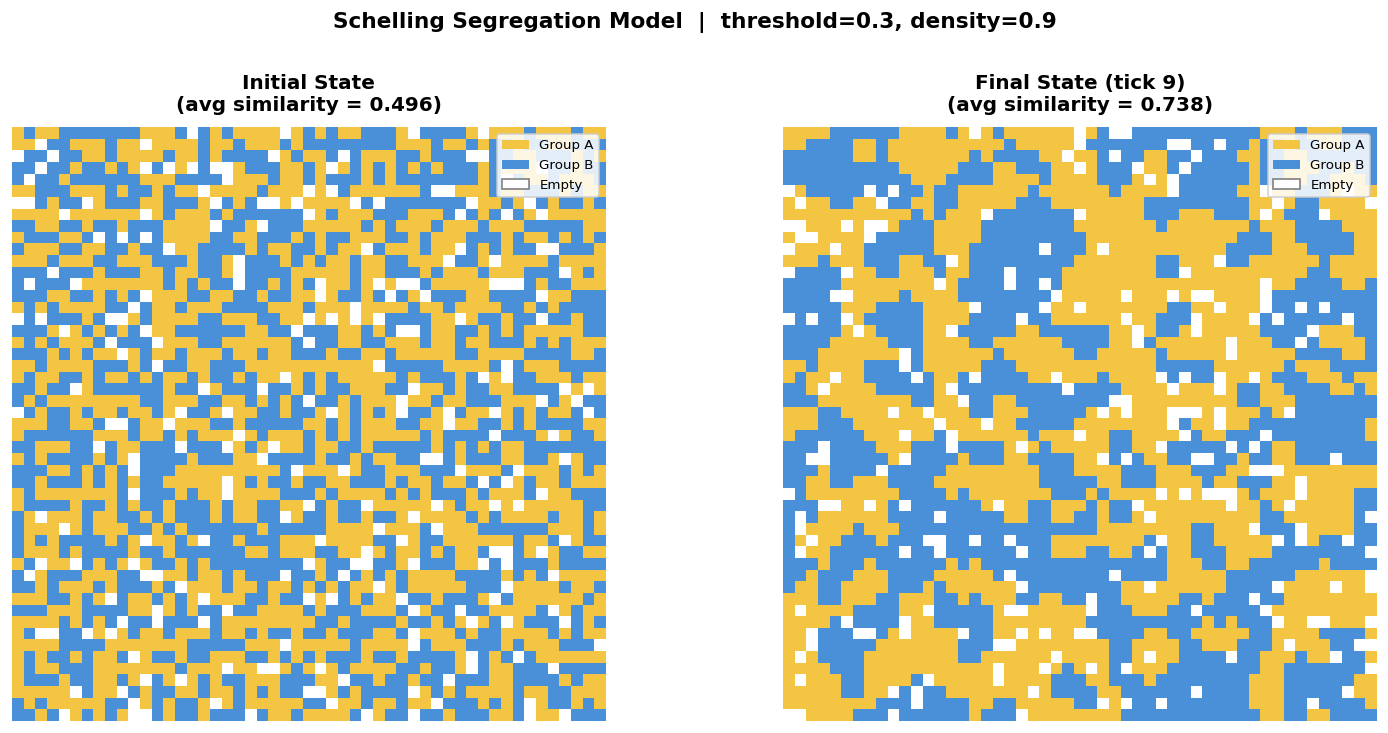

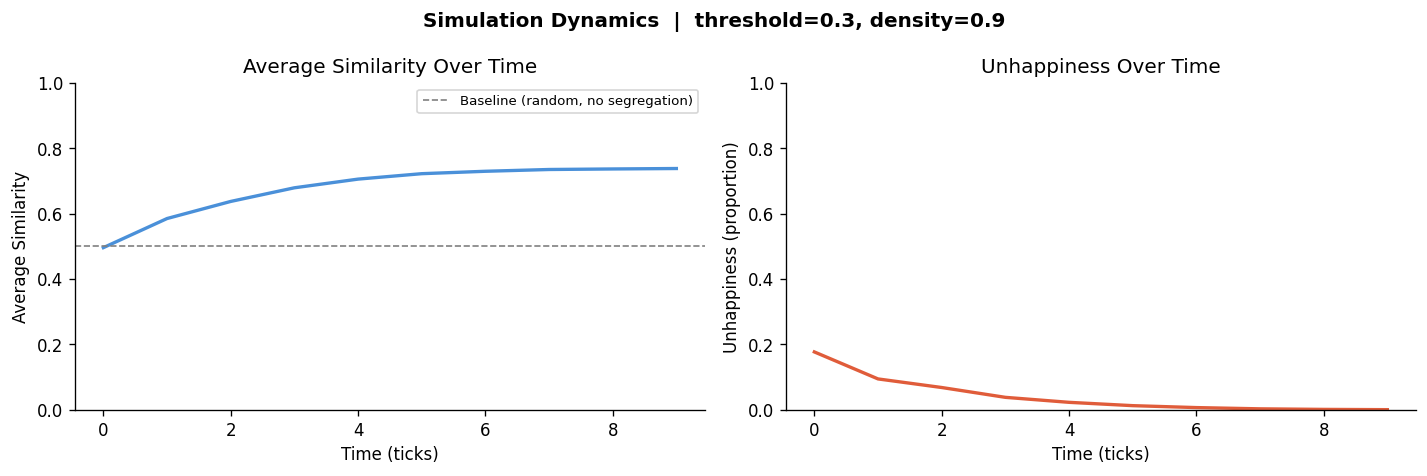


Key result:
  Threshold (individual preference): 0.3
  Final avg similarity (population): 0.738
  → Segregation is much stronger than individual preference suggests.


In [10]:
# Re-run to capture the initial state for comparison
np.random.seed(SEED)
agents_initial = initialize_agents(GRID_SIZE, DENSITY, N_COLORS)
grid_initial   = build_grid_lookup(agents_initial, GRID_SIZE)
update_agents(agents_initial, grid_initial, GRID_SIZE, SIMILARITY_THRESHOLD)

# ── Figure: Before & After ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

draw_grid(agents_initial, GRID_SIZE,
          title=f'Initial State\n(avg similarity = {history["average_similarity"].iloc[0]:.3f})',
          ax=axes[0])

draw_grid(agents, GRID_SIZE,
          title=f'Final State (tick {ticks_run})\n(avg similarity = {history["average_similarity"].iloc[-1]:.3f})',
          ax=axes[1])

plt.suptitle(f'Schelling Segregation Model  |  threshold={SIMILARITY_THRESHOLD}, density={DENSITY}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Figure: Time Series ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Average similarity over time
axes[0].plot(history['tick'], history['average_similarity'],
             color='#4A90D9', linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1,
                label='Baseline (random, no segregation)')
axes[0].set_xlabel('Time (ticks)')
axes[0].set_ylabel('Average Similarity')
axes[0].set_title('Average Similarity Over Time')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

# Unhappiness over time
axes[1].plot(history['tick'], history['unhappiness'],
             color='#E05C3A', linewidth=2)
axes[1].set_xlabel('Time (ticks)')
axes[1].set_ylabel('Unhappiness (proportion)')
axes[1].set_title('Unhappiness Over Time')
axes[1].set_ylim(0, 1)

plt.suptitle(f'Simulation Dynamics  |  threshold={SIMILARITY_THRESHOLD}, density={DENSITY}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nKey result:")
print(f"  Threshold (individual preference): {SIMILARITY_THRESHOLD}")
print(f"  Final avg similarity (population): {history['average_similarity'].iloc[-1]:.3f}")
print(f"  → Segregation is much stronger than individual preference suggests.")


## 11. Parameter Sweep — Varying the Similarity Threshold

This is the core scientific question of the Schelling model:

> *How much population-level segregation emerges from how mild an individual preference?*

We run the simulation across a range of `similarity_threshold` values and record
the final `average_similarity` for each. This is a **parameter sweep** — a key
tool for characterizing model behavior (Section 3.7.2).

Because simulations are stochastic, we run **multiple replicates** per parameter
value (a **batch**) and plot the mean and spread.

## Interpreting the result

Look at the gap between what individuals want and what the population produces. An agent with threshold 0.30 is saying "I'm fine as long as 30% of my neighbors are like me." That's a very tolerant person — they're happy being a minority. Yet the population ends up with 74.7% average similarity. That's not a slightly segregated city, that's a heavily segregated one.

## Three Zones in the Data

**Zone 1 — Thresholds 0.05 and 0.10 (mean_sim ≈ 0.508**
Almost no segregation beyond the random baseline of 0.5. At these thresholds agents are so tolerant that almost nobody ever moves, and the initial random placement is essentially the final state.

**Zone 2 — Thresholds 0.15 to 0.50 (mean_sim jumps from 0.555 to 0.871)**
This is where the Schelling effect is most dramatic. Notice the big jump between 0.25 → 0.30 (0.579 → 0.747). This suggests a tipping point somewhere around 0.25–0.30 — a threshold value above which segregation escalates sharply. This is a classic signature of emergence: a small change in individual behavior produces a large, non-linear change in collective outcome.

**Zone 3 — Thresholds 0.55 and above (mean_sim → 1.0)**
Near-total segregation. At 0.70, average similarity is 0.994 — essentially every agent is surrounded exclusively by same-color neighbors. The city is fully sorted.


In [11]:
# ── Parameter sweep settings ──────────────────────────────────────────────────

# 🌐 Global sweep parameters
THRESHOLDS  = np.arange(0.05, 0.75, 0.05)  # threshold values to test
N_REPS      = 10                             # replicates per threshold (increase for smoother results)
SWEEP_TICKS = 200                            # max ticks per run

# 📍 Local — storage for results
sweep_results = []

print(f"Running {len(THRESHOLDS)} thresholds x {N_REPS} replicates "
      f"= {len(THRESHOLDS) * N_REPS} total simulations...\n")

for threshold in THRESHOLDS:                 # 📍 Local — current threshold value
    rep_similarities = []                    # 📍 Local — results for this threshold

    for rep in range(N_REPS):               # 📍 Local — replicate index
        _, history_rep, _ = run_simulation(
            grid_size            = GRID_SIZE,
            density              = DENSITY,
            similarity_threshold = threshold,
            n_colors             = N_COLORS,
            max_ticks            = SWEEP_TICKS,
            seed                 = rep       # different seed per replicate
        )
        final_sim = history_rep['average_similarity'].iloc[-1]  # 📍 Local
        rep_similarities.append(final_sim)

    sweep_results.append({
        'threshold':  threshold,
        'mean_sim':   np.mean(rep_similarities),
        'std_sim':    np.std(rep_similarities),
        'min_sim':    np.min(rep_similarities),
        'max_sim':    np.max(rep_similarities),
    })
    print(f"  threshold={threshold:.2f}  →  avg similarity = {np.mean(rep_similarities):.3f}")

sweep_df = pd.DataFrame(sweep_results)  # 📍 Local → will display below
sweep_df


Running 14 thresholds x 10 replicates = 140 total simulations...

  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 2
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 2
  ✓ Equilibrium reached at tick 2
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 2
  ✓ Equilibrium reached at tick 2
  threshold=0.05  →  avg similarity = 0.509
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 2
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 2
  ✓ Equilibrium reached at tick 2
  ✓ Equilibrium reached at tick 1
  ✓ Equilibrium reached at tick 2
  ✓ Equilibrium reached at tick 2
  threshold=0.10  →  avg similarity = 0.509
  ✓ Equilibrium reached at tick 6
  ✓ Equilibrium reached at tick 4
  ✓ Equilibrium reached at tick 6
  ✓ Equilibrium reached at tick 9
  ✓ Equilibrium reached at tic

,threshold,mean_sim,std_sim,min_sim,max_sim
0,0.05,0.508502,0.006153,0.497555,0.515029
1,0.10,0.508502,0.006153,0.497555,0.515029
2,0.15,0.555367,0.008550,0.544695,0.569634
3,0.20,0.574227,0.010905,0.556193,0.592672
4,0.25,0.578663,0.010445,0.562729,0.597711
5,0.30,0.747334,0.011474,0.721159,0.769769
6,0.35,0.765132,0.012304,0.744442,0.787184
7,0.40,0.823223,0.007988,0.811138,0.835950
8,0.45,0.870748,0.006466,0.859267,0.881593
9,0.50,0.870748,0.006466,0.859267,0.881593


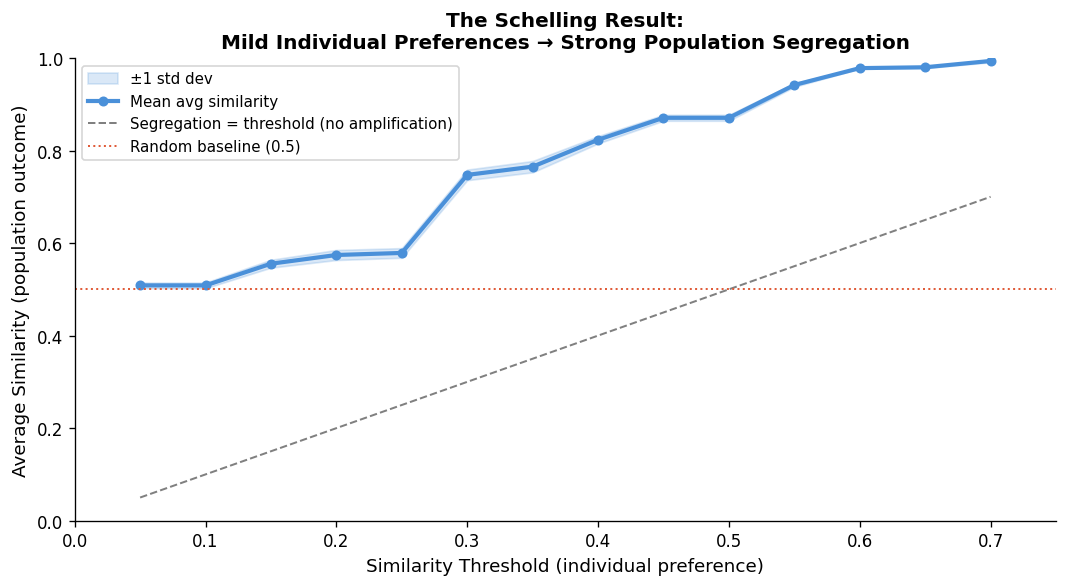


The gap between the gray dashed line and the blue line is the Schelling effect:
population-level segregation is MUCH stronger than individual preference alone.


In [12]:
# ── Plot the sweep results ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

# Shaded band: mean ± std
ax.fill_between(sweep_df['threshold'],
                sweep_df['mean_sim'] - sweep_df['std_sim'],
                sweep_df['mean_sim'] + sweep_df['std_sim'],
                alpha=0.2, color='#4A90D9', label='±1 std dev')

# Mean line
ax.plot(sweep_df['threshold'], sweep_df['mean_sim'],
        color='#4A90D9', linewidth=2.5, marker='o', markersize=5,
        label='Mean avg similarity')

# Diagonal reference line: if population segregation = individual threshold
ax.plot(sweep_df['threshold'], sweep_df['threshold'],
        color='gray', linestyle='--', linewidth=1.2,
        label='Segregation = threshold (no amplification)')

# Baseline
ax.axhline(0.5, color='#E05C3A', linestyle=':', linewidth=1.2,
           label='Random baseline (0.5)')

ax.set_xlabel('Similarity Threshold (individual preference)', fontsize=11)
ax.set_ylabel('Average Similarity (population outcome)', fontsize=11)
ax.set_title("The Schelling Result:\nMild Individual Preferences → Strong Population Segregation",
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.75)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\nThe gap between the gray dashed line and the blue line is the Schelling effect:")
print("population-level segregation is MUCH stronger than individual preference alone.")


## 12. Null Model — What Happens Without Preferences?

A **null model** removes the mechanism of interest to establish a baseline.

Here, the null model is: agents move to random empty cells *regardless* of their
neighbors' colors. There is no homophily, no threshold, no preference.

If we see `average_similarity ≈ 0.5` in the null model but `average_similarity >> 0.5`
in the full model, we know the difference is caused by the threshold mechanism —
not just by random movement or initialization.


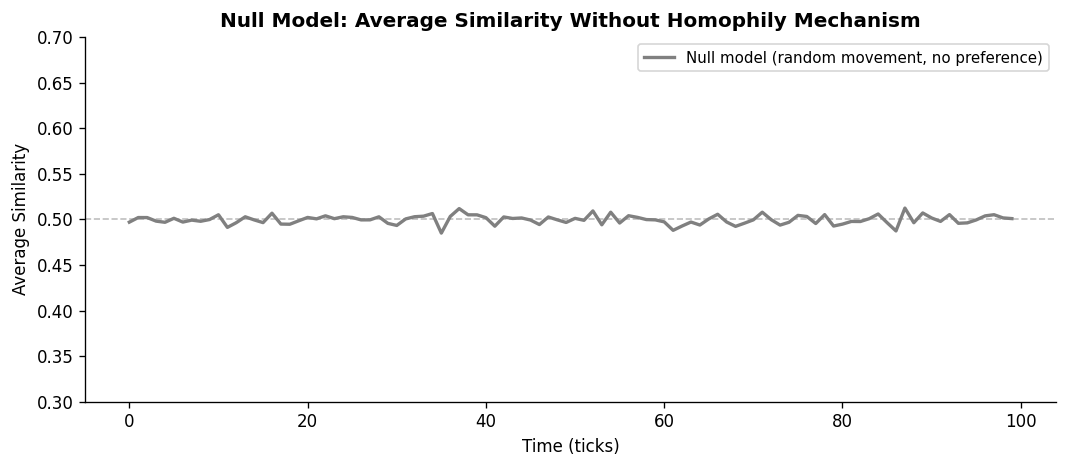

Null model average similarity (mean over time): 0.500
Expected for 2 equal groups, no segregation:    ~0.500

This confirms the baseline — random movement alone does NOT produce segregation.


In [13]:
def run_null_model(grid_size, density, n_colors, n_ticks=100, seed=None):
    """
    Run the null (neutral) version of the Schelling model.

    Agents move to random empty cells at each tick WITHOUT checking their
    neighborhood composition. There is no similarity threshold — movement
    is completely random.

    This establishes what average_similarity looks like in the ABSENCE
    of the homophily mechanism.

    Parameters
    ----------
    grid_size : int   🌐
    density   : float 🌐
    n_colors  : int   🌐
    n_ticks   : int   — number of time steps to run
    seed      : int   — random seed

    Returns
    -------
    history : pd.DataFrame — time series of average_similarity
    """
    if seed is not None:
        np.random.seed(seed)

    # Initialize with threshold = 0 → all agents always happy → no one moves
    # Instead we force all agents to move every tick by setting threshold = 1.1
    # (impossible to satisfy → everyone always moves)

    agents = initialize_agents(grid_size, density, n_colors)
    grid   = build_grid_lookup(agents, grid_size)

    # For the null model: force all agents to be unhappy so they all move randomly
    agents['happy'] = False

    null_history = []

    for tick in range(n_ticks):          # 📍 Local — tick index
        move_unhappy_agents(agents, grid, grid_size)

        # Compute prop_similar for measurement ONLY (not used for decisions)
        update_agents(agents, grid, grid_size, similarity_threshold=1.1)
        avg_sim, _ = compute_globals(agents)

        null_history.append({'tick': tick, 'average_similarity': avg_sim})

        # Reset all agents to unhappy so they move again next tick
        agents['happy'] = False

    return pd.DataFrame(null_history)


# ── Run null model ────────────────────────────────────────────────────────────
null_history = run_null_model(GRID_SIZE, DENSITY, N_COLORS, n_ticks=100, seed=SEED)

# ── Plot comparison ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(null_history['tick'], null_history['average_similarity'],
        color='gray', linewidth=2, label='Null model (random movement, no preference)')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Time (ticks)')
ax.set_ylabel('Average Similarity')
ax.set_title('Null Model: Average Similarity Without Homophily Mechanism', fontweight='bold')
ax.set_ylim(0.3, 0.7)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

null_mean = null_history['average_similarity'].mean()
print(f"Null model average similarity (mean over time): {null_mean:.3f}")
print(f"Expected for 2 equal groups, no segregation:    ~0.500")
print(f"\nThis confirms the baseline — random movement alone does NOT produce segregation.")


## 13. Summary and Key Findings

### What we built
A complete Python implementation of Schelling's segregation model with:
- A discrete square grid with toroidal boundaries
- Agents with group identities and a local happiness threshold
- Moore neighborhood (8 surrounding cells, radius r=1)
- Visualization of spatial state and time-series dynamics
- Parameter sweep over similarity thresholds
- A null model baseline

### Key findings
1. **Emergence:** Population-level segregation is far stronger than individual
   preferences. An agent happy with just 30% similar neighbors still produces
   a heavily segregated city. The macro outcome is not readable from the micro rule.

2. **The Schelling effect:** In the parameter sweep, the average similarity curve
   sits well above the diagonal — the gray dashed "no amplification" line.
   Small thresholds produce disproportionately large segregation.

3. **Null model confirms the mechanism:** When agents move randomly (no threshold),
   average similarity hovers near 0.5. The segregation we observe in the full model
   is caused by the threshold mechanism, not by random dynamics.

### Variable types recap
| Scope | Examples in this model |
|---|---|
| 🌐 **Global** | `GRID_SIZE`, `DENSITY`, `SIMILARITY_THRESHOLD`, `grid`, `agents`, `average_similarity`, `unhappiness` |
| 🤖 **Agent** | `row`, `col`, `color`, `happy`, `prop_similar` |
| 📍 **Local** | `neighbor_cells`, `total_nearby`, `similar_nearby`, `empty_cells`, `new_pos` |
